# Store Sales — Time Series Forecasting

**Task:** forecast product sales in Favorita stores 16 days ahead.

**Data:** Kaggle competition `Store Sales - Time Series Forecasting`.

**Metric:** RMSLE. It fits sales data well: it reduces the impact of very large values and handles zeros safely through `log1p`.

**Project structure:** the pipeline is split into three notebooks — `01_eda` (this one), `02_feature_engineering` and `03_modeling_submission`.

> 🇷🇺 **Задача:** спрогнозировать продажи товаров в магазинах Favorita на 16 дней вперёд. **Метрика:** RMSLE — подходит для продаж, снижает влияние больших значений и аккуратно работает с нулями через `log1p`. Пайплайн разбит на три ноутбука: EDA, feature engineering и моделирование.

In [1]:
import time; _t0 = time.time()

# Base libraries / Базовые библиотеки
import os
import warnings
warnings.filterwarnings('ignore') 

# Data handling / Работа с данными
import numpy as np
import pandas as pd

# Visualization / Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Time series and statistics / Временные ряды и статистика
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

# Model / Модель
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.optimize import minimize


In [2]:
KAGGLE_PATH = "/kaggle/input/competitions/store-sales-time-series-forecasting"
LOCAL_PATH  = "../data"

DATA_PATH = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

train        = pd.read_csv(os.path.join(DATA_PATH, "train.csv"),           parse_dates=["date"])
test         = pd.read_csv(os.path.join(DATA_PATH, "test.csv"),            parse_dates=["date"])
oil          = pd.read_csv(os.path.join(DATA_PATH, "oil.csv"),             parse_dates=["date"])
holidays     = pd.read_csv(os.path.join(DATA_PATH, "holidays_events.csv"), parse_dates=["date"])
stores       = pd.read_csv(os.path.join(DATA_PATH, "stores.csv"))
transactions = pd.read_csv(os.path.join(DATA_PATH, "transactions.csv"),    parse_dates=["date"])

print("DATA_PATH:", DATA_PATH)
print(f"train: {train.shape}, test: {test.shape}")

DATA_PATH: ../data
train: (3000888, 6), test: (28512, 5)


## EDA

First I check the table structure, missing values, date ranges and the behaviour of the target. The goal of EDA is not just to draw plots, but to understand which features the model needs.

> 🇷🇺 Сначала проверяю структуру таблиц, пропуски, диапазоны дат и поведение целевой переменной. Цель EDA — не просто построить графики, а понять, какие признаки нужны модели.

In [3]:
print(train.shape)
train.info()

(3000888, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [4]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [6]:
print(test.shape)
test.info()

(28512, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


In [7]:
test.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [8]:
print(oil.shape)
oil.info()

(1218, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


In [9]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [10]:
oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

#### Missing values in oil

The `oil` table has two kinds of gaps:

- not all calendar dates are present, because the oil price is not published every day;
- some `dcoilwtico` values are missing even for existing dates.

Before merging with train/test I rebuild the daily calendar and fill the price with linear interpolation.

> 🇷🇺 В таблице `oil` два типа пропусков: отсутствующие даты (цена публикуется не каждый день) и пропущенные значения `dcoilwtico`. Перед объединением с train/test восстанавливаю ежедневный календарь и заполняю цену линейной интерполяцией.

In [11]:
print(holidays.shape)
holidays.info()

(350, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


In [12]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [13]:
holidays.isnull().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [14]:
print(stores.shape)
stores.info()

(54, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [15]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [16]:
stores.isnull().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [17]:
print(transactions.shape)
transactions.info()

(83488, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


In [18]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [19]:
transactions.isnull().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

#### Column descriptions

**train**
| Column        | Type     | Description                          |
| ------------- | -------- | ------------------------------------ |
| `id`          | int64    | Unique record id                     |
| `date`        | datetime | Sale date                            |
| `store_nbr`   | int64    | Store id                             |
| `family`      | object   | Product family                       |
| `sales`       | float64  | Units sold                           |
| `onpromotion` | int64    | Number of items on promotion         |

**oil**
| Column       | Type     | Description     |
| ------------ | -------- | --------------- |
| `date`       | datetime | Date            |
| `dcoilwtico` | float64  | Oil price (WTI) |

**holidays**
| Column        | Type     | Description                                  |
| ------------- | -------- | -------------------------------------------- |
| `date`        | datetime | Event date                                   |
| `type`        | object   | Event type (holiday, extra day off, etc.)    |
| `locale`      | object   | Level (National / Regional / Local)          |
| `locale_name` | object   | Region or city name                          |
| `description` | object   | Event name                                   |
| `transferred` | bool     | Whether the holiday was moved                |

**stores**
| Column      | Type   | Description                          |
|-------------|--------|--------------------------------------|
| `store_nbr` | int64  | Unique store id                      |
| `city`      | object | Store city                           |
| `state`     | object | State / region                       |
| `type`      | object | Store type (format/size)             |
| `cluster`   | int64  | Store cluster (similar stores group) |

**transactions**
| Column          | Type     | Description                           |
|-----------------|----------|---------------------------------------|
| `date`          | datetime | Date                                  |
| `store_nbr`     | int64    | Store id                              |
| `transactions`  | int64    | Number of transactions (purchases)    |

> 🇷🇺 Описание столбцов всех пяти таблиц: train (продажи по магазину и категории), oil (цена нефти WTI), holidays (события с типом, уровнем и флагом переноса), stores (город, штат, тип, кластер), transactions (число покупок по магазину и дате).

In [20]:
# Check date ranges in all tables / Проверяем диапазоны дат во всех таблицах

date_tables = {
    "train": train,
    "test": test,
    "oil": oil,
    "holidays": holidays,
    "transactions": transactions,
}

for name, df in date_tables.items():
    print(f"Date range in {name}:")
    print("min:", df["date"].min())
    print("max:", df["date"].max())
    print()




Date range in train:
min: 2013-01-01 00:00:00
max: 2017-08-15 00:00:00

Date range in test:
min: 2017-08-16 00:00:00
max: 2017-08-31 00:00:00

Date range in oil:
min: 2013-01-01 00:00:00
max: 2017-08-31 00:00:00

Date range in holidays:
min: 2012-03-02 00:00:00
max: 2017-12-26 00:00:00

Date range in transactions:
min: 2013-01-01 00:00:00
max: 2017-08-15 00:00:00



#### Date ranges

- `train` ends on 2017-08-15, `test` starts on 2017-08-16 — there is no gap between them.
- `oil` covers the whole train + test period, but the calendar must be rebuilt to daily frequency.
- `holidays` contains dates outside train/test, so only the relevant dates are used for features.
- `transactions` exist only for the train period. For test I use lags of 16–23 days, so the values always point to known historical data.

> 🇷🇺 `train` заканчивается 2017-08-15, `test` начинается 2017-08-16 — разрыва нет. `oil` покрывает весь период, но календарь нужно достроить. `holidays` содержит даты за пределами train/test. `transactions` есть только для train — поэтому для test используются лаги 16–23 дня.

#### Visual analysis of the time series

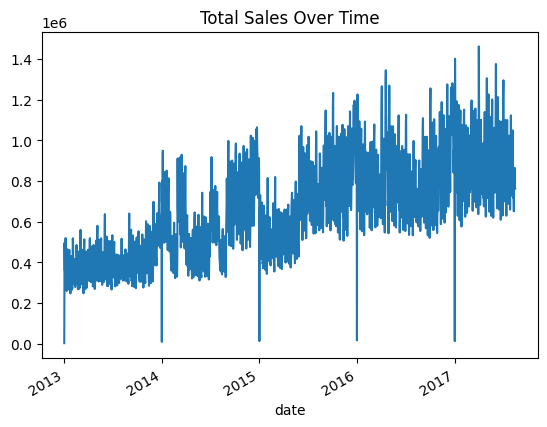

In [21]:
# Overall sales trend / Общий тренд продаж
daily_sales = train.groupby("date")["sales"].sum()

plt.figure()
daily_sales.plot(title="Total Sales Over Time")
plt.show()

- December 25 is missing from the raw train data for most years: stores are closed, so during preprocessing these dates are added with zero sales.
- Total sales grow towards 2016–2017, but 2017 is incomplete and cannot be compared directly with full years.

> 🇷🇺 25 декабря отсутствует в train для большинства лет (магазины закрыты) — при препроцессинге эти даты добавляются с нулевыми продажами. Продажи растут к 2016–2017, но 2017 год неполный.

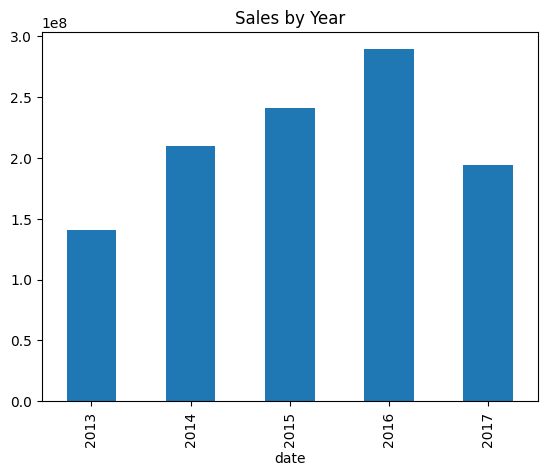

In [22]:
# Compare sales by year / Сравниваем продажи по годам
train.groupby(train["date"].dt.year)["sales"].sum().plot(
    kind="bar", title="Sales by Year"
)
plt.show()

Sales for 2017 are incomplete — the data ends on 2017-08-15.

> 🇷🇺 Продажи за 2017 год неполные — данные до 2017-08-15.

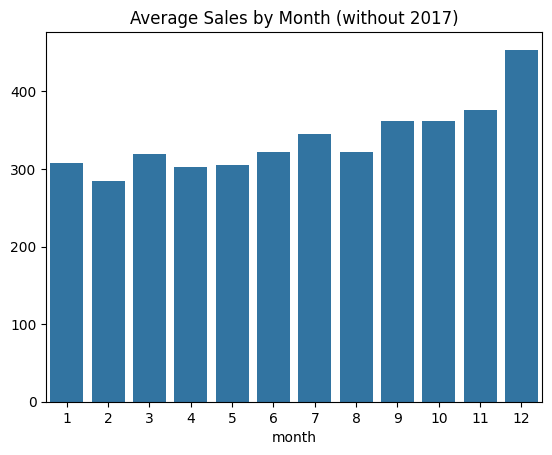

In [23]:
# Compare months without 2017 because it is incomplete / Сравниваем месяцы без неполного 2017 года
train["month"] = train["date"].dt.month

month_sales = (
    train[train["date"].dt.year != 2017]
    .groupby("month")["sales"]
    .mean()
)

sns.barplot(x=month_sales.index, y=month_sales.values)
plt.title("Average Sales by Month (without 2017)")
plt.show()

The plots show weekly and monthly seasonality. That is why I add calendar features and cyclic Fourier features later.

> 🇷🇺 На графиках видна недельная и месячная сезонность. Поэтому дальше добавляю календарные признаки и циклические Fourier-признаки.

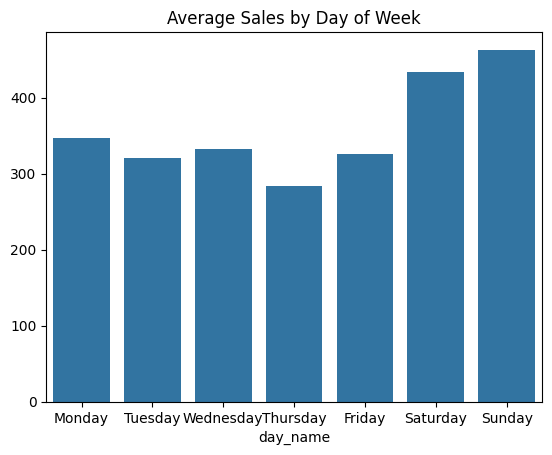

In [24]:
# Compare sales by weekday / Сравниваем продажи по дням недели
train["day_name"] = train["date"].dt.day_name()

dow_sales = train.groupby("day_name")["sales"].mean()

# Fix the weekday order / Фиксируем порядок дней недели
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.barplot(x=dow_sales.index, y=dow_sales.values, order=order)
plt.title("Average Sales by Day of Week")
plt.show()

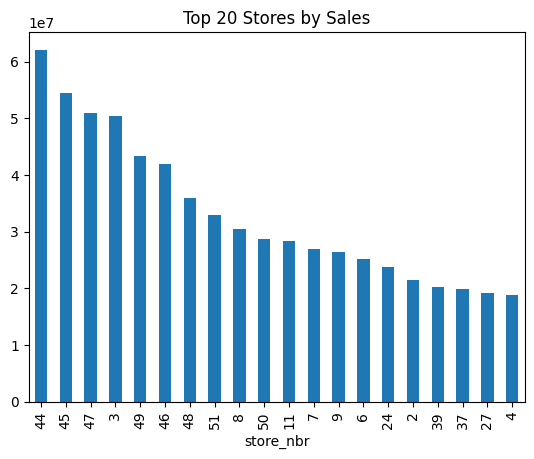

In [25]:
# Total sales per store / Суммарные продажи по магазинам
store_sales = train.groupby("store_nbr")["sales"].sum().sort_values(ascending=False)

store_sales.head(20).plot(kind="bar", title="Top 20 Stores by Sales")
plt.show()

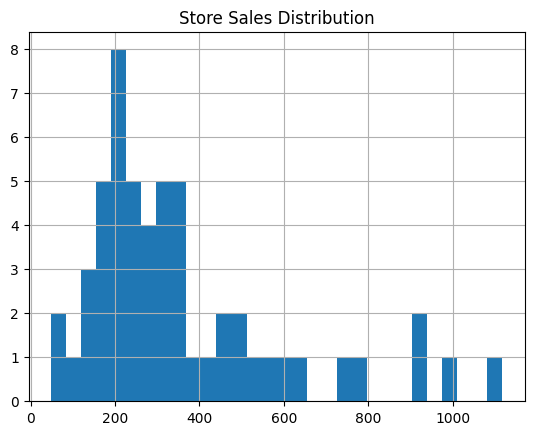

In [26]:
# Average daily sales per store / Средние дневные продажи по магазинам
train.groupby("store_nbr")["sales"].mean().hist(bins=30)
plt.title("Store Sales Distribution")
plt.show()

- Store type and cluster are clearly related to the sales level, so I use them as categorical features.
- Stores differ a lot in sales scale, so `store_nbr` also stays in the model.

> 🇷🇺 Тип и кластер магазина заметно связаны с уровнем продаж — использую их как категориальные признаки. Магазины сильно различаются по масштабу, поэтому `store_nbr` тоже остаётся в модели.

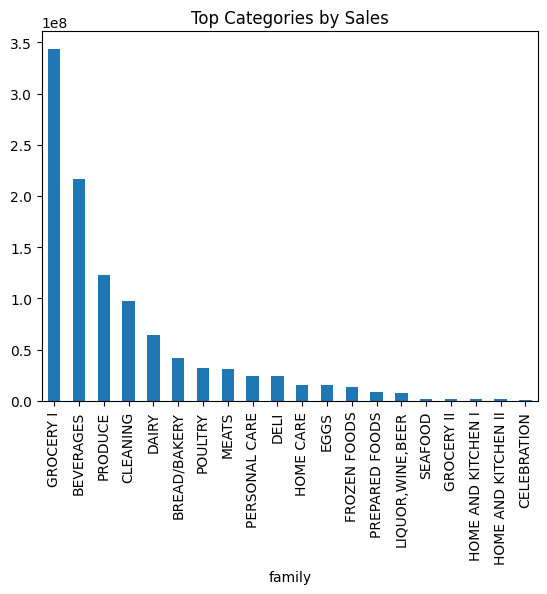

In [27]:
# Compare sales by product family / Сравниваем продажи по категориям товаров
family_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False)

family_sales.head(20).plot(kind="bar", title="Top Categories by Sales")
plt.show()

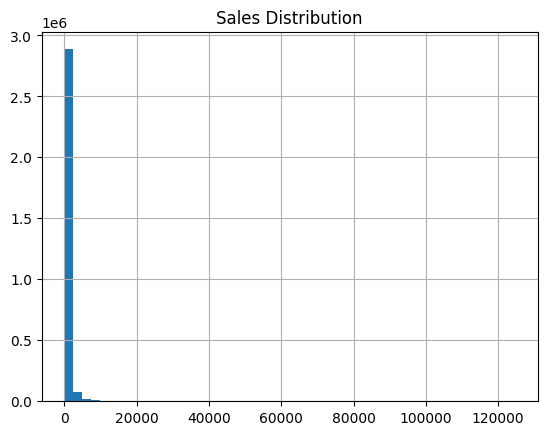

In [28]:
# Target distribution / Распределение целевой переменной
train["sales"].hist(bins=50)
plt.title("Sales Distribution")
plt.show()

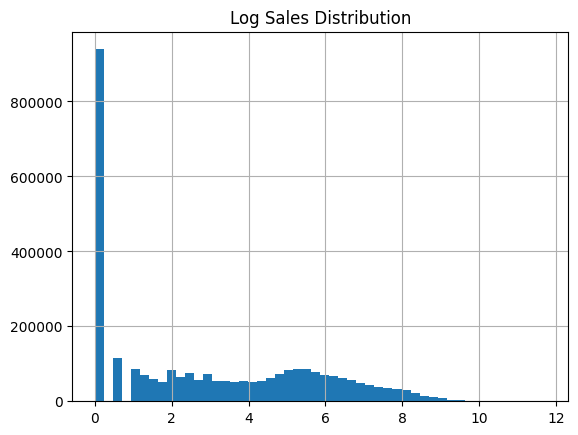

In [29]:
# Target distribution, log scale for readability / Распределение таргета, логарифм для наглядности
np.log1p(train["sales"]).hist(bins=50)
plt.title("Log Sales Distribution")
plt.show()

#### Target distribution (`sales`)

`sales` is strongly right-skewed: most values are small, but rare very large sales exist.

After the `log1p` transform the distribution becomes more compact and the model overfits less to outliers.

> 🇷🇺 `sales` сильно скошена вправо: большинство значений небольшие, но встречаются очень большие продажи. После `log1p` распределение компактнее, модель меньше переобучается на выбросы.

In [30]:
(train["sales"] == 0).mean()

np.float64(0.3129506999261552)

About **31%** of observations have zero sales. This is normal for retail: not every product sells every day in every store.

The model handles this in two ways:

- the `log1p` transform works correctly with zeros;
- the zero-rule in the final forecast predicts 0 for series where the last 21 train days were also zero.

> 🇷🇺 Около **31%** наблюдений — нулевые продажи, для ритейла это нормально. Учитывается двумя способами: `log1p` корректно работает с нулями, а zero-rule ставит 0 рядам, у которых последние 21 день train тоже нулевые.

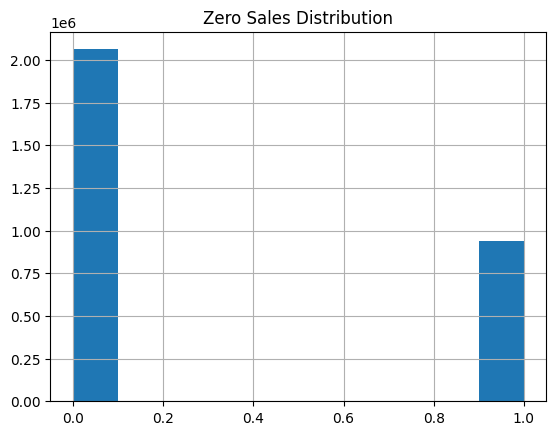

In [31]:
train["sales"].eq(0).astype(int).hist()
plt.title("Zero Sales Distribution")
plt.show()

In [32]:
# Share of zero sales per family / Доля нулевых продаж по категориям
zero_by_family = train.groupby("family")["sales"].apply(lambda x: (x == 0).mean())

# Families with the most zeros / Категории с наибольшей долей нулей
zero_by_family.sort_values(ascending=False).head(10)

family
BOOKS                         0.969550
BABY CARE                     0.941310
SCHOOL AND OFFICE SUPPLIES    0.740829
HOME APPLIANCES               0.735176
LADIESWEAR                    0.598465
MAGAZINES                     0.565387
PET SUPPLIES                  0.546153
HARDWARE                      0.478622
LAWN AND GARDEN               0.467846
PLAYERS AND ELECTRONICS       0.448865
Name: sales, dtype: float64

Some product families have more than 70% zero sales. Demand differs a lot between families, so `family` must stay as a feature.

> 🇷🇺 У некоторых категорий доля нулевых продаж выше 70%. Спрос по категориям очень разный, поэтому `family` обязательно остаётся признаком.

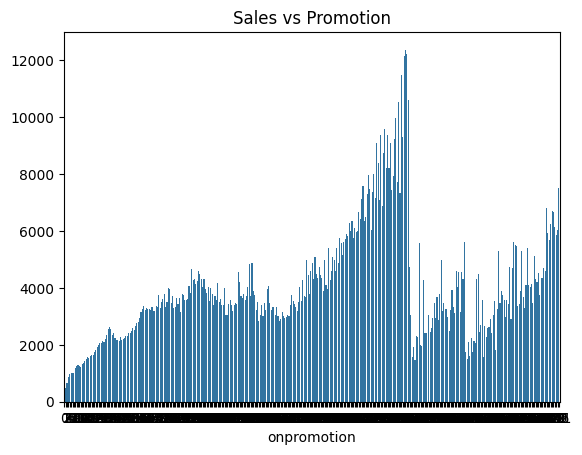

In [33]:
# Average sales vs promotions / Средние продажи в зависимости от промо
promo_sales = train.groupby("onpromotion")["sales"].mean()

# Plot the promo-sales relation / Визуализируем связь промо и продаж
sns.barplot(x=promo_sales.index, y=promo_sales.values)
plt.title("Sales vs Promotion")
plt.show()

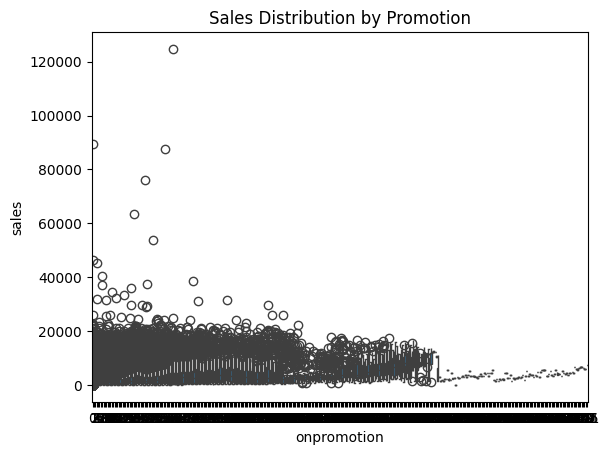

In [34]:
# Sales distribution by promo count / Распределение продаж при разном количестве промо
sns.boxplot(x=train["onpromotion"], y=train["sales"])
plt.title("Sales Distribution by Promotion")
plt.show()

In [35]:
# Correlation between sales and promotions / Корреляция между продажами и промо
train[["sales", "onpromotion"]].corr()

,sales,onpromotion
sales,1.000000,0.427923
onpromotion,0.427923,1.000000


There is a strong positive relation between promotions and sales. It does not prove causality, but `onpromotion` is clearly useful for forecasting.

> 🇷🇺 Между промо и продажами сильная положительная связь. Это не доказывает причинность, но `onpromotion` явно полезен для прогноза.

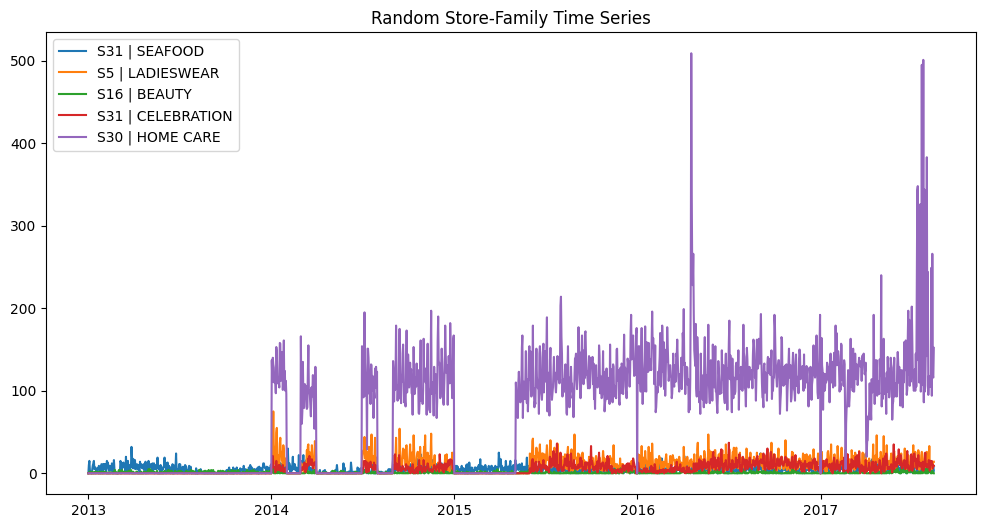

In [36]:
# Individual store x family series / Отдельные ряды магазин x категория
plt.figure(figsize=(12,6))

samples = train[["store_nbr", "family"]].drop_duplicates().sample(5, random_state=42)

for _, row in samples.iterrows():
    sample = train[
        (train["store_nbr"] == row["store_nbr"]) &
        (train["family"] == row["family"])
    ]
    
    ts = sample.groupby("date")["sales"].sum()
    plt.plot(ts, label=f"S{row['store_nbr']} | {row['family']}")

plt.legend()
plt.title("Random Store-Family Time Series")
plt.show()

Looking at individual `store_nbr × family` series shows:

- long periods with zero sales happen;
- the sales scale differs a lot between products and stores;
- weekly and seasonal patterns are visible;
- individual series are more volatile than the aggregated plot.

This leads to the key features: sales lags, rolling means, `store_nbr`, `family`, `store_type` and `cluster`.

> 🇷🇺 Отдельные ряды `store_nbr × family` показывают: длинные нулевые периоды, разный масштаб продаж, недельные и сезонные паттерны, высокую волатильность. Отсюда ключевые признаки: лаги, rolling-средние, `store_nbr`, `family`, `store_type`, `cluster`.

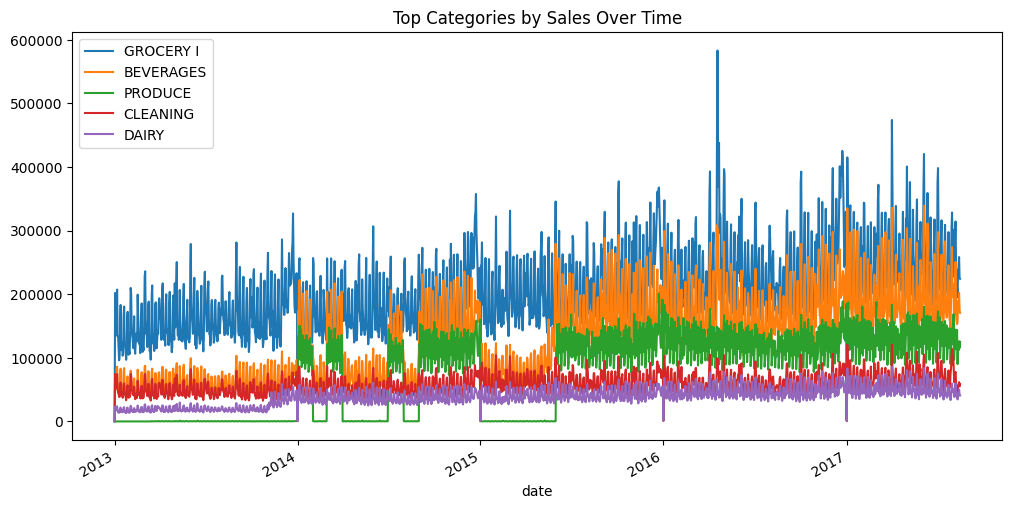

In [37]:
# Top-5 families by total sales / Топ-5 категорий по суммарным продажам
top_families = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12,6))

for fam in top_families:
    sample = train[train["family"] == fam]
    sample.groupby("date")["sales"].sum().plot(label=fam)

plt.legend()
plt.title("Top Categories by Sales Over Time")
plt.show()

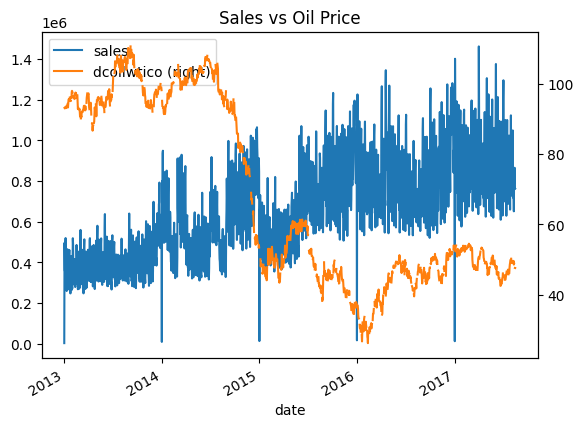

In [38]:
# Sales vs oil price / Сравниваем продажи и цену нефти
merged = (
    train.groupby("date")["sales"]
    .sum()
    .reset_index()
    .merge(oil, on="date", how="left")
)

merged.plot(x="date", y=["sales", "dcoilwtico"], secondary_y="dcoilwtico")
plt.title("Sales vs Oil Price")
plt.show()

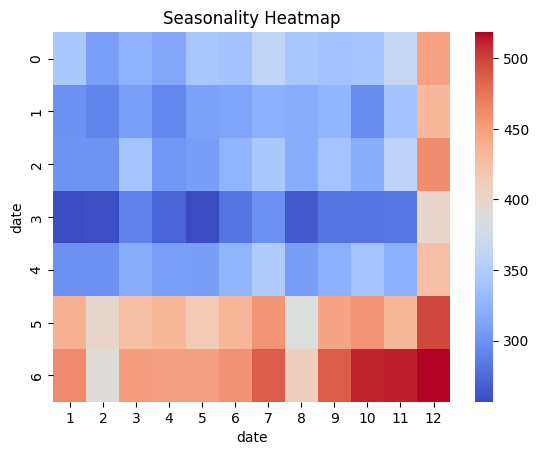

In [39]:
# Seasonality heatmap by weekday and month / Тепловая карта сезонности по дням недели и месяцам

pivot = train.groupby([
    train["date"].dt.dayofweek,
    train["date"].dt.month
])["sales"].mean().unstack()

sns.heatmap(pivot, cmap="coolwarm")
plt.title("Seasonality Heatmap")
plt.show()

The heatmap confirms weekly and monthly seasonality. The model captures it through `day_of_week`, `month`, `week_of_year` and Fourier features.

> 🇷🇺 Тепловая карта подтверждает недельную и месячную сезонность. В модели это отражено через `day_of_week`, `month`, `week_of_year` и Fourier-признаки.

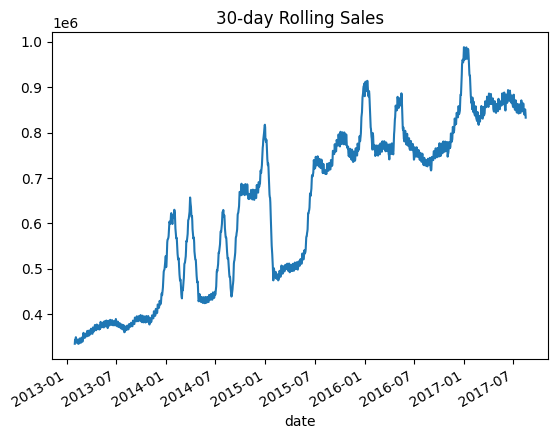

In [40]:
# 30-day rolling mean of the sales trend / 30-дневное скользящее среднее тренда продаж
train.groupby("date")["sales"].sum().rolling(30).mean().plot()
plt.title("30-day Rolling Sales")
plt.show()

The 30-day rolling mean shows overall sales growth until 2017 and regular peaks. The model needs trend features, lags and calendar seasonality.

> 🇷🇺 30-дневное скользящее среднее показывает общий рост продаж до 2017 года и регулярные пики. Для модели нужны признаки тренда, лаги и календарная сезонность.

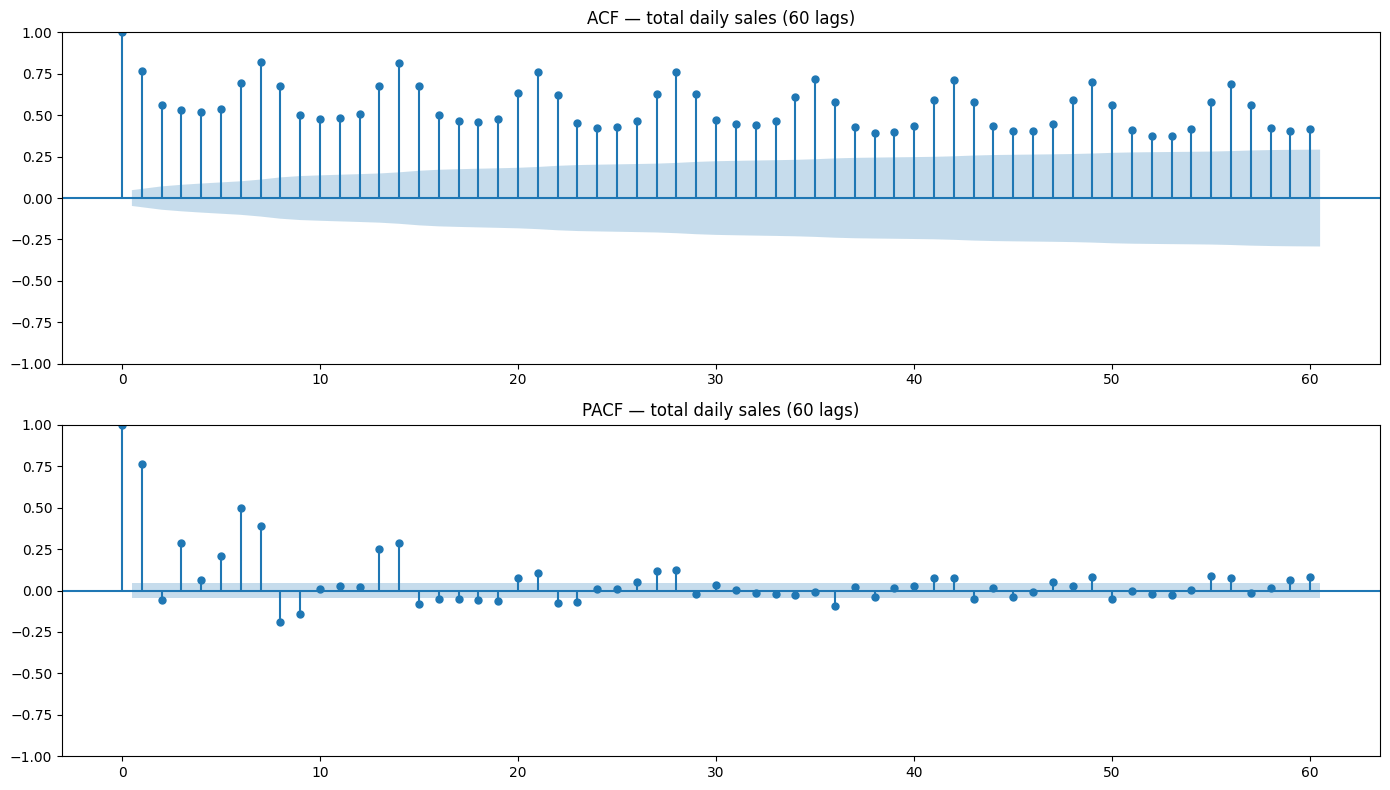

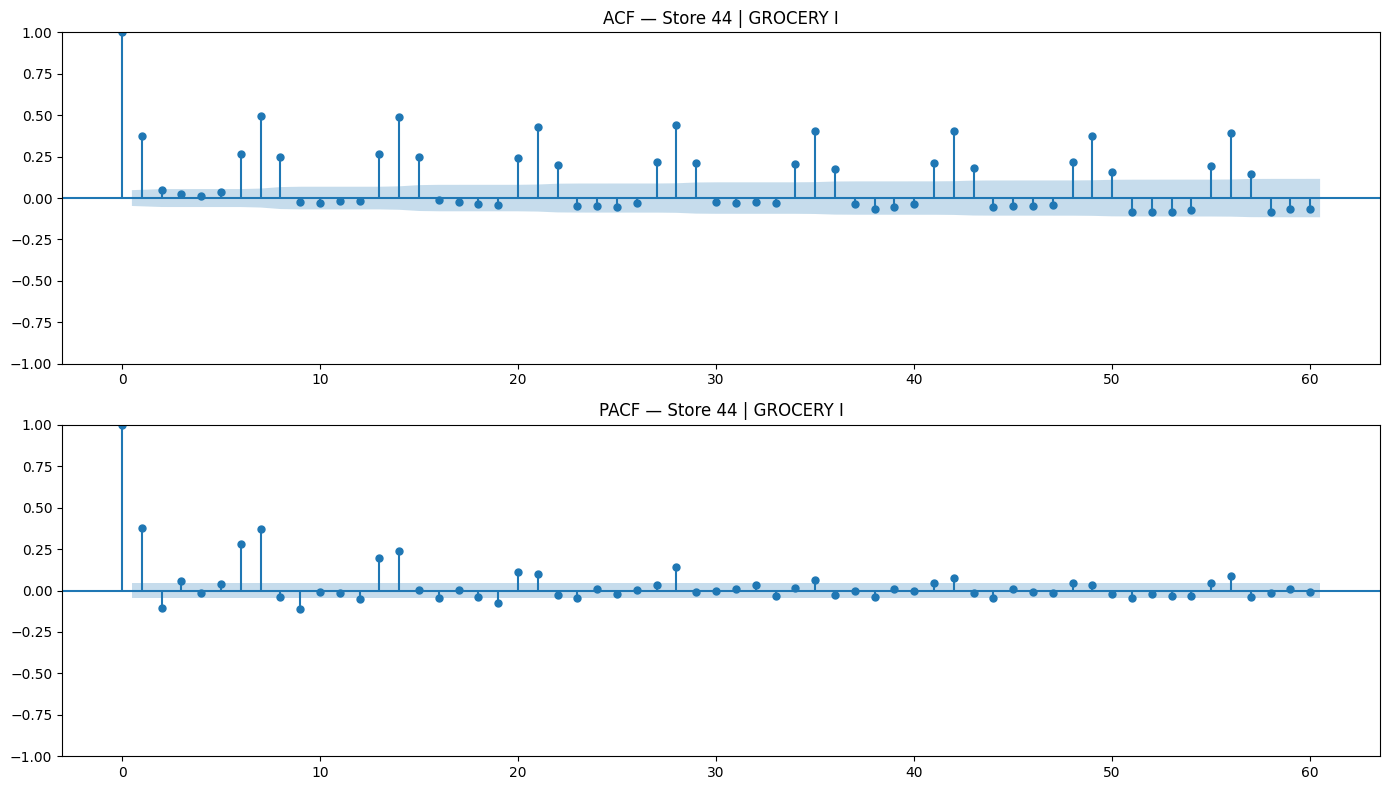

Significant ACF lags (up to 30):  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Significant PACF lags (up to 30): [1, 2, 3, 4, 5, 6, 7, 8, 9, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28]

Significance bound: ±0.0487


In [41]:
# Aggregate sales to a daily series / Агрегируем продажи до дневного ряда
daily_sales = train.groupby("date")["sales"].sum().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_sales, lags=60, ax=axes[0], title="ACF — total daily sales (60 lags)")
plot_pacf(daily_sales, lags=60, ax=axes[1], title="PACF — total daily sales (60 lags)", method="ywm")

plt.tight_layout()
plt.show()

# Also check ACF/PACF for one large series / Дополнительно смотрим ACF/PACF для одного крупного ряда
# Take the largest store and the best-selling family / Берём самый крупный магазин и самую продаваемую категорию
top_store = train.groupby("store_nbr")["sales"].sum().idxmax()
top_family = train.groupby("family")["sales"].sum().idxmax()

single_ts = (
    train[(train["store_nbr"] == top_store) & (train["family"] == top_family)]
    .groupby("date")["sales"]
    .sum()
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(single_ts, lags=60, ax=axes[0],
         title=f"ACF — Store {top_store} | {top_family}")
plot_pacf(single_ts, lags=60, ax=axes[1],
          title=f"PACF — Store {top_store} | {top_family}", method="ywm")

plt.tight_layout()
plt.show()

# Significant lags for total daily sales / Значимые лаги для суммарных дневных продаж

acf_vals = acf(daily_sales, nlags=30, alpha=0.05)
pacf_vals = pacf(daily_sales, nlags=30, alpha=0.05, method="ywm")

# Approximate significance bound 2/sqrt(n) / Приближённая граница значимости 2/sqrt(n)
conf_bound = 2 / np.sqrt(len(daily_sales))

sig_acf_lags = [i for i in range(1, 31) if abs(acf_vals[0][i]) > conf_bound]
sig_pacf_lags = [i for i in range(1, 31) if abs(pacf_vals[0][i]) > conf_bound]

print(f"Significant ACF lags (up to 30):  {sig_acf_lags}")
print(f"Significant PACF lags (up to 30): {sig_pacf_lags}")
print(f"\nSignificance bound: ±{conf_bound:.4f}")

#### ACF / PACF — conclusions

**ACF**: lags 1–30 are significant. This is typical for a series with trend and seasonality: past values stay informative for a long time.

**PACF** shows the direct relation with individual lags:

| PACF lags | Interpretation |
|---|---|
| 1–9 | Short-term dynamics and the weekly cycle |
| 13–23 | Two- and three-week patterns |
| 26–28 | Near-monthly effect |

**How this is used in the model:**

- `lag_1`–`lag_6` — short-term dynamics of the last days;
- `lag_7`, `lag_14`, `lag_21`, `lag_28` — weekly cycles;
- `lag_42`, `lag_56` — longer 6–8-week cycles;
- `lag_364`, `lag_365` — sales about one year ago;
- `rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28`, `rolling_mean_364` — smoothed sales history.

> 🇷🇺 ACF: лаги 1–30 значимы (тренд + сезонность). PACF выделяет короткие лаги 1–9, двух-трёхнедельные 13–23 и околомесячные 26–28. В модели: `lag_1`–`lag_6`, недельные 7/14/21/28, длинные 42/56, годовые 364/365 и rolling-средние.

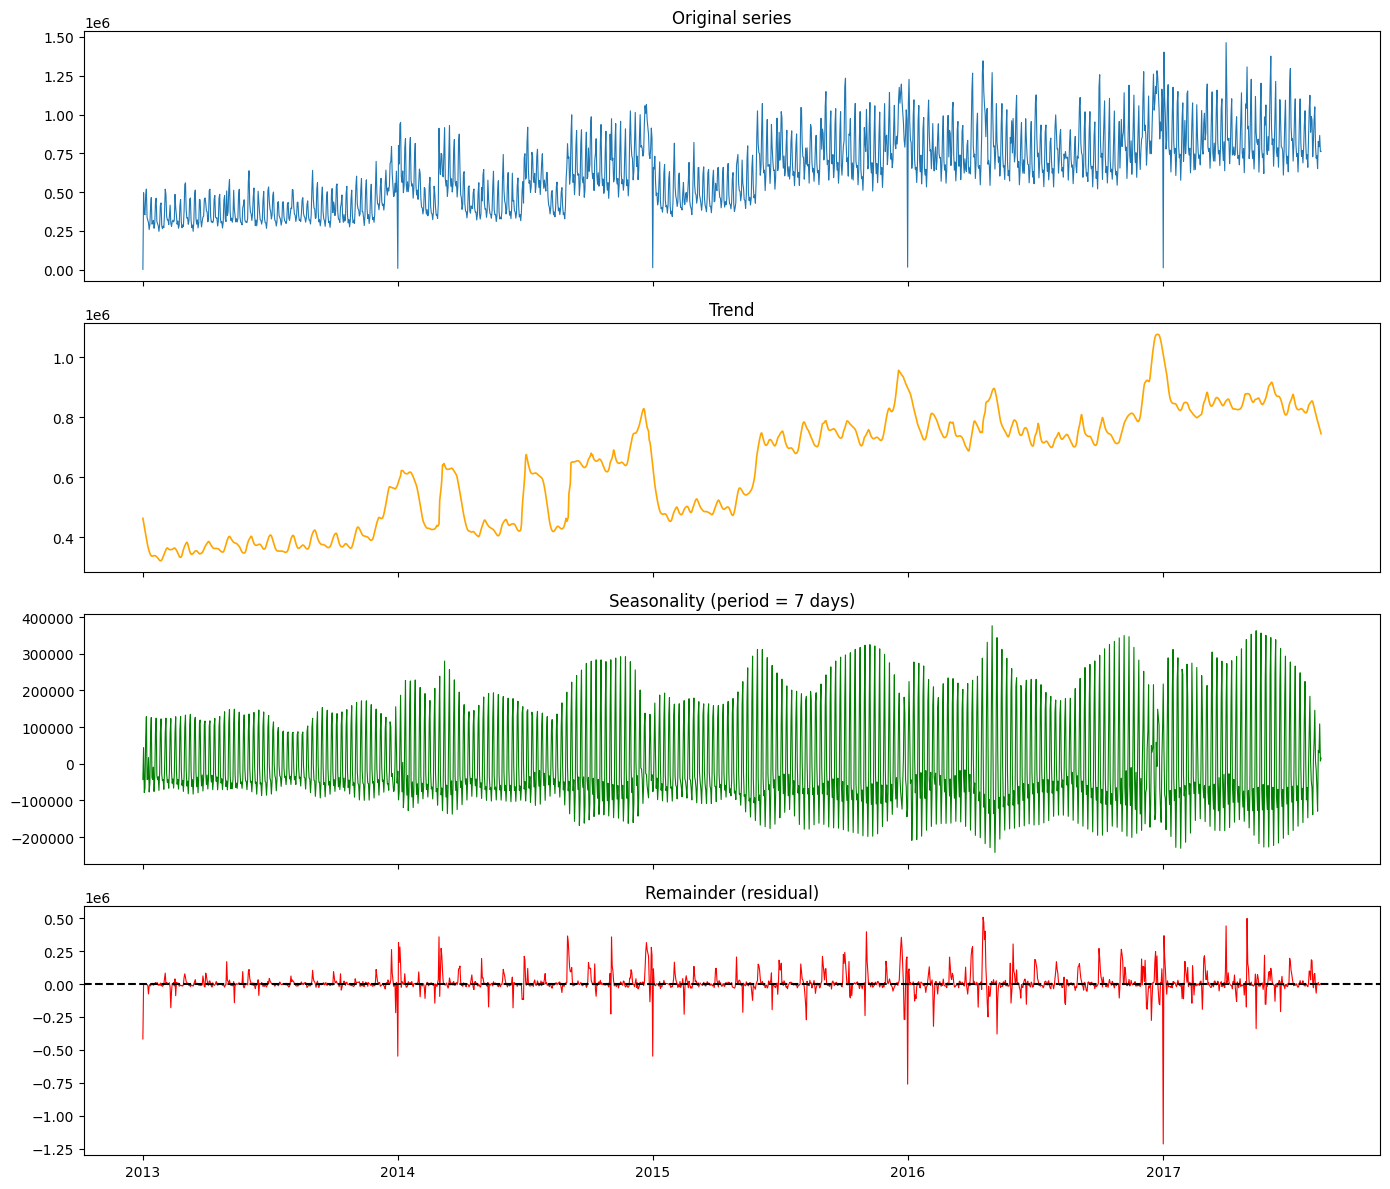

Trend strength:       0.838  (0 — none, 1 — very strong)
Seasonality strength: 0.644  (0 — none, 1 — very strong)


In [42]:
# Total daily sales / Суммарные дневные продажи
daily_sales = train.groupby("date")["sales"].sum().sort_index()

# STL decomposition with weekly period / STL-декомпозиция с недельным периодом
stl = STL(daily_sales, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(result.observed, linewidth=0.8)
axes[0].set_title("Original series")

axes[1].plot(result.trend, color="orange", linewidth=1.2)
axes[1].set_title("Trend")

axes[2].plot(result.seasonal, color="green", linewidth=0.8)
axes[2].set_title("Seasonality (period = 7 days)")

axes[3].plot(result.resid, color="red", linewidth=0.8)
axes[3].axhline(0, linestyle="--", color="black")
axes[3].set_title("Remainder (residual)")

plt.tight_layout()
plt.show()

# Strength of trend and seasonality / Сила тренда и сезонности
var_resid = result.resid.var()
var_trend = (result.trend + result.resid).var()
var_seasonal = (result.seasonal + result.resid).var()

strength_trend = max(0, 1 - var_resid / var_trend)
strength_seasonal = max(0, 1 - var_resid / var_seasonal)

print(f"Trend strength:       {strength_trend:.3f}  (0 — none, 1 — very strong)")
print(f"Seasonality strength: {strength_seasonal:.3f}  (0 — none, 1 — very strong)")

#### STL decomposition — conclusions

| Component | Strength | Interpretation |
|---|---|---|
| Trend | **0.838** — very strong | Sales grow over the long horizon |
| Seasonality | **0.644** — moderately strong | The weekly pattern is clear but does not explain the whole series |

**Trend** is captured through sales history: lags, rolling means and `date_index`.

**Seasonality** is encoded with calendar and Fourier features: `day_of_week`, `month`, `week_of_year`, `sin_day`, `cos_day`, `sin_week`, `cos_week`.

**The remainder** contains anomalies: the Manabí earthquake, holidays, commercial events. Separate binary flags are added for them.

> 🇷🇺 STL: тренд 0.838 (очень сильный), сезонность 0.644 (умеренная). Тренд учитывается лагами, rolling-средними и `date_index`; сезонность — календарными и Fourier-признаками; остаток содержит аномалии (землетрясение, праздники, события) — для них отдельные бинарные флаги.

<Axes: xlabel='city'>

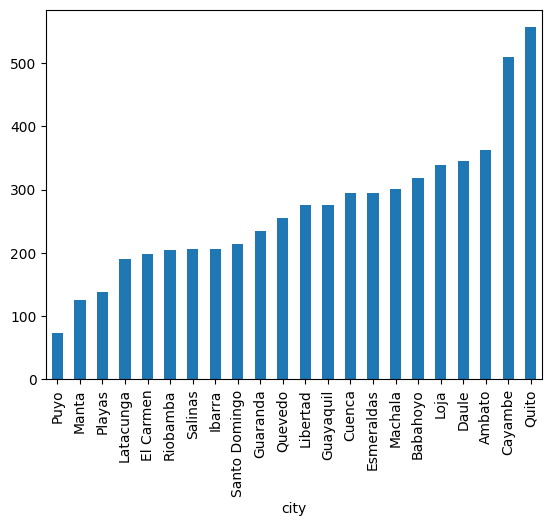

In [43]:
# Compare sales by city / Сравниваем продажи по городам
# Using the stores table / Используем таблицу stores
train.merge(stores, on="store_nbr").groupby("city")["sales"].mean().sort_values().plot(kind="bar")


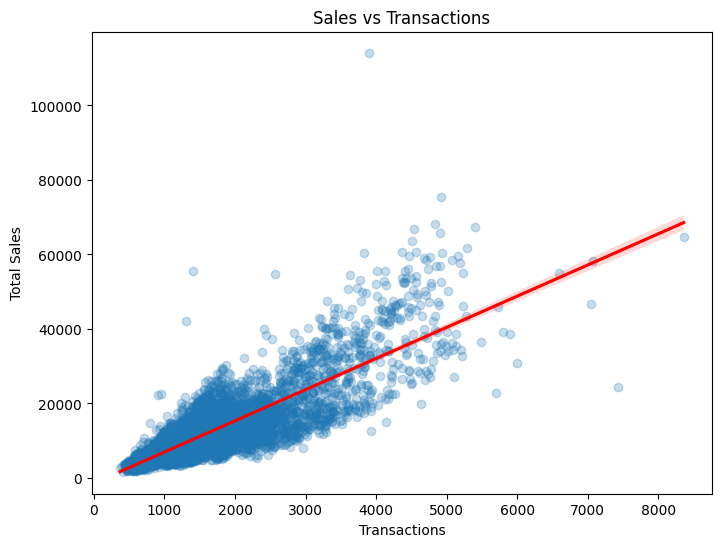

In [44]:
# Merge daily store sales with transactions / Объединяем дневные продажи магазина с транзакциями
sales_transactions = (
    train.groupby(["date", "store_nbr"])["sales"]
    .sum()
    .reset_index()
    .merge(transactions, on=["date", "store_nbr"], how="inner")
)

# Plot the sales-transactions relation on a sample / Связь продаж и транзакций на подвыборке
plt.figure(figsize=(8, 6))
sns.regplot(
    data=sales_transactions.sample(5000, random_state=42),
    x="transactions",
    y="sales",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.title("Sales vs Transactions")
plt.xlabel("Transactions")
plt.ylabel("Total Sales")
plt.show()


In [45]:
# Holiday effect on sales / Влияние праздников на продажи

# Prepare data for the holiday analysis / Готовим данные для анализа праздников
def prepare_holiday_features(train, holidays, stores):

    # Exclude transferred holidays / Исключаем перенесённые праздники
    hol = holidays[holidays["transferred"] == False].copy()

    # Add store city and state / Добавляем город и штат магазина
    train_h = train.merge(
        stores[["store_nbr", "city", "state"]],
        on="store_nbr",
        how="left"
    )

    # Merge with the holidays table / Объединяем с таблицей праздников
    train_h = train_h.merge(
        hol[["date", "locale", "locale_name", "description"]],
        on="date",
        how="left"
    )

    # Check whether the holiday applies to this store / Проверяем, относится ли праздник к магазину
    def is_real_holiday(row):
        if pd.isna(row["locale"]): return 0
        if row["locale"] == "National": return 1
        if row["locale"] == "Regional" and row["locale_name"] == row["state"]: return 1
        if row["locale"] == "Local" and row["locale_name"] == row["city"]: return 1
        return 0

    # Flag for a relevant holiday / Флаг релевантного праздника
    train_h["is_holiday"] = train_h.apply(is_real_holiday, axis=1)

    # Average sales as the baseline level / Средние продажи как базовый уровень
    baseline = (
        train.groupby(["store_nbr", "family"])["sales"]
        .mean()
        .rename("baseline")
        .reset_index()
    )

    # Add the baseline to the data / Добавляем базовый уровень к данным
    train_h = train_h.merge(baseline, on=["store_nbr", "family"], how="left")

    # Normalize sales by the baseline / Нормализуем продажи относительно базового уровня
    train_h["sales_ratio"] = train_h["sales"] / (train_h["baseline"] + 1e-6)

    return train_h

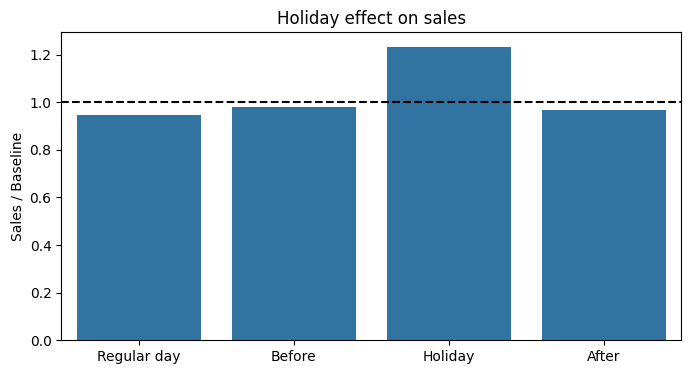

In [46]:

# Effect on the holiday, the day before and after / Эффект в день праздника, до и после него

train_h = prepare_holiday_features(train, holidays, stores)

# Dates of relevant holidays / Даты релевантных праздников
holiday_dates = train_h.loc[train_h["is_holiday"] == 1, "date"].drop_duplicates()

# Offset relative to the holiday / Смещение относительно праздника
train_h["day_offset"] = None

# Holiday itself / День праздника
train_h.loc[train_h["is_holiday"] == 1, "day_offset"] = 0

# Day before the holiday / День до праздника
train_h.loc[
    (train_h["is_holiday"] == 0) &
    (train_h["date"] + pd.Timedelta(days=1)).isin(holiday_dates),
    "day_offset"
] = -1

# Day after the holiday / День после праздника
train_h.loc[
    (train_h["is_holiday"] == 0) &
    (train_h["date"] - pd.Timedelta(days=1)).isin(holiday_dates),
    "day_offset"
] = 1

# All other days are regular / Остальные дни считаем обычными
train_h["day_offset"] = train_h["day_offset"].fillna(99)

# Average effect / Средний эффект
sales_window = (
    train_h
    .groupby("day_offset")["sales_ratio"]
    .mean()
    .reindex([99, -1, 0, 1])
    .reset_index()
)

# Labels for the plot / Подписи для графика
sales_window["day_label"] = sales_window["day_offset"].map({
    99: "Regular day",
    -1: "Before",
     0: "Holiday",
     1: "After"
})

# Draw the plot / Строим график
plt.figure(figsize=(8, 4))

sns.barplot(
    data=sales_window,
    x="day_label",
    y="sales_ratio",
    order=["Regular day", "Before", "Holiday", "After"]
)

plt.axhline(1, linestyle="--", color="black")
plt.title("Holiday effect on sales")
plt.ylabel("Sales / Baseline")
plt.xlabel("")

plt.show()

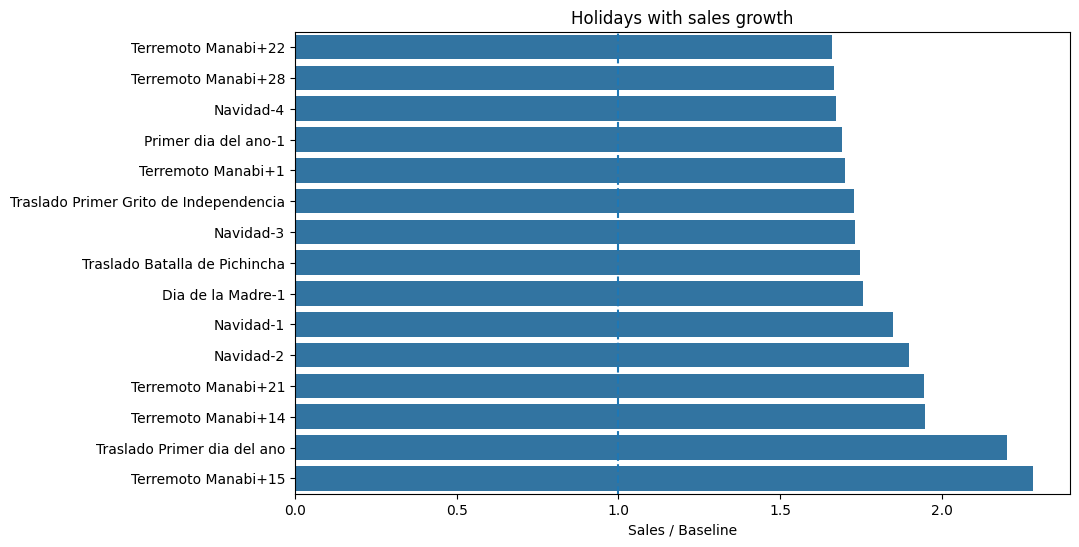

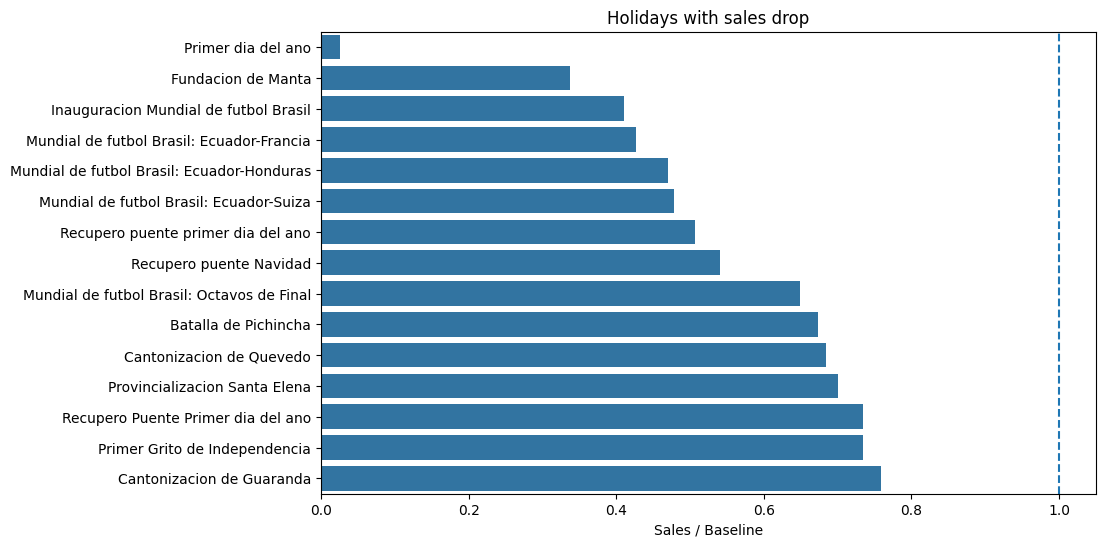

In [47]:
# Effect by holiday name / Эффект по названиям праздников

train_h = prepare_holiday_features(train, holidays, stores)

# Keep only relevant holidays / Оставляем только релевантные праздники
train_h = train_h[train_h["is_holiday"] == 1].copy()

# Average effect by holiday / Средний эффект по типам праздников
holiday_effect = (
    train_h
    .groupby("description")["sales_ratio"]
    .agg(["mean", "count"])
    .reset_index()
)

# Drop rare events / Убираем редкие события
holiday_effect = holiday_effect[holiday_effect["count"] > 50]

# Sort by average effect / Сортируем по среднему эффекту
holiday_effect = holiday_effect.sort_values("mean")

# Holidays with the biggest sales growth / Праздники с ростом продаж
plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_effect.tail(15), x="mean", y="description")
plt.axvline(1, linestyle="--")
plt.title("Holidays with sales growth")
plt.xlabel("Sales / Baseline")
plt.ylabel("")
plt.show()

# Holidays with the biggest sales drop / Праздники с падением продаж
plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_effect.head(15), x="mean", y="description")
plt.axvline(1, linestyle="--")
plt.title("Holidays with sales drop")
plt.xlabel("Sales / Baseline")
plt.ylabel("")
plt.show()

In [48]:
# Unique holiday names / Уникальные названия праздников
holidays["description"].unique()

array(['Fundacion de Manta', 'Provincializacion de Cotopaxi',
       'Fundacion de Cuenca', 'Cantonizacion de Libertad',
       'Cantonizacion de Riobamba', 'Cantonizacion del Puyo',
       'Cantonizacion de Guaranda', 'Provincializacion de Imbabura',
       'Cantonizacion de Latacunga', 'Fundacion de Machala',
       'Fundacion de Santo Domingo', 'Cantonizacion de El Carmen',
       'Cantonizacion de Cayambe', 'Fundacion de Esmeraldas',
       'Primer Grito de Independencia', 'Fundacion de Riobamba',
       'Fundacion de Ambato', 'Fundacion de Ibarra',
       'Cantonizacion de Quevedo', 'Independencia de Guayaquil',
       'Traslado Independencia de Guayaquil', 'Dia de Difuntos',
       'Independencia de Cuenca', 'Provincializacion de Santo Domingo',
       'Provincializacion Santa Elena', 'Independencia de Guaranda',
       'Independencia de Latacunga', 'Independencia de Ambato',
       'Fundacion de Quito-1', 'Fundacion de Quito', 'Fundacion de Loja',
       'Navidad-4', 'Cantonizac

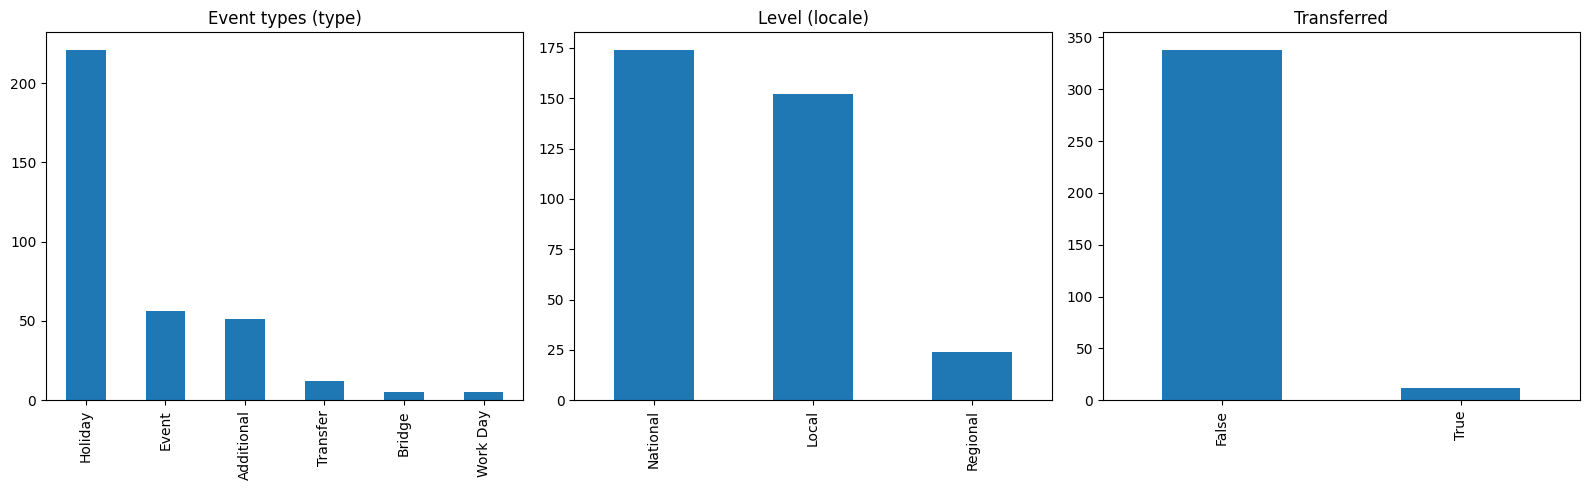

Events by category:
event_category
City / province foundation    158
New Year / Christmas           55
Independence / battle days     48
Manabi earthquake              31
Other                          20
Football World Cup             14
Carnival                       10
Day of the Dead                 8
Black Friday                    3
Cyber Monday                    3


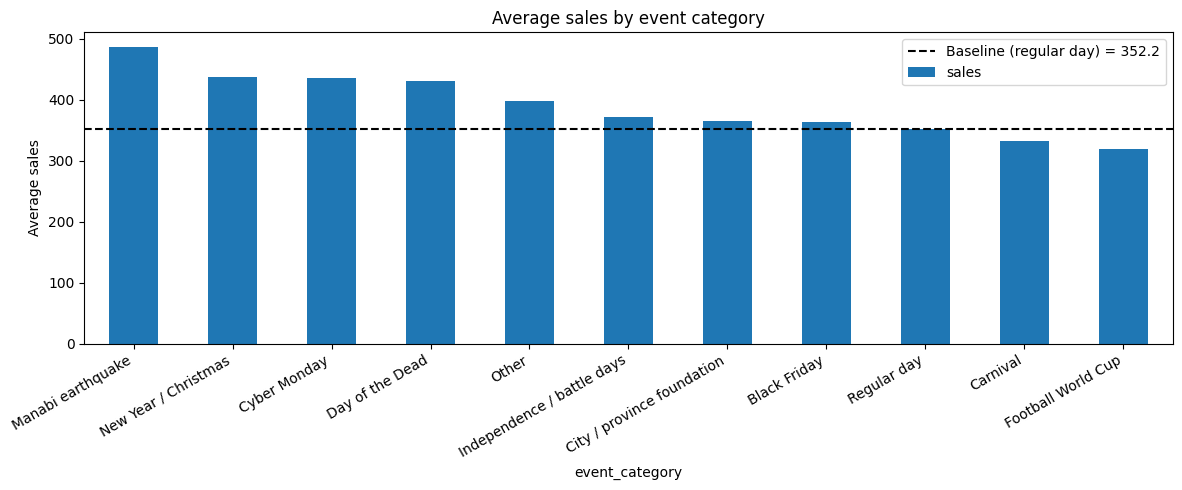

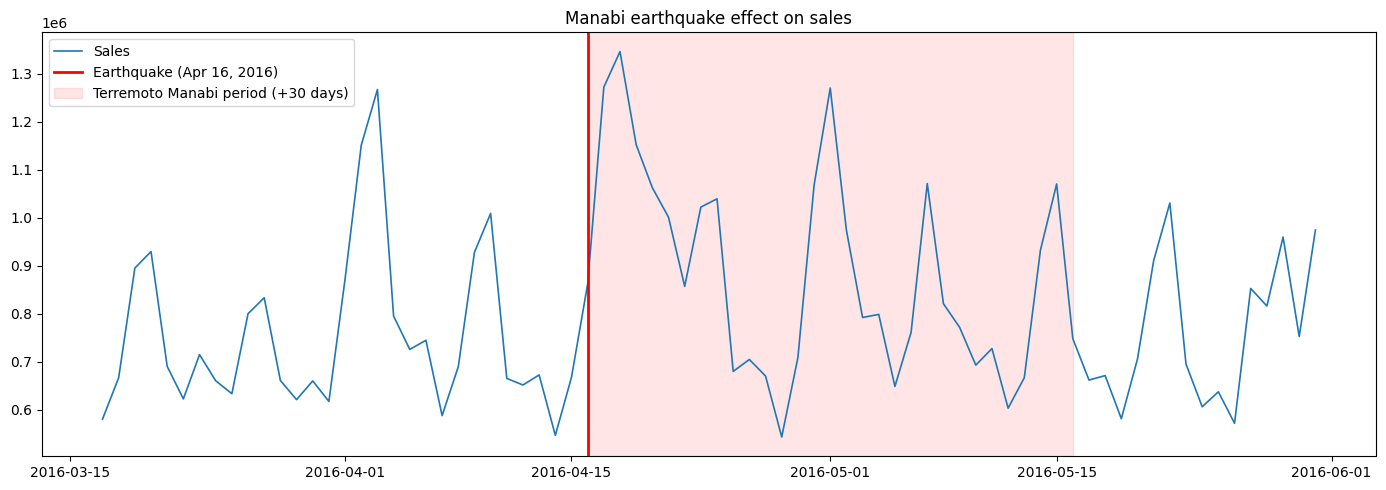

Average sales 30 days BEFORE:   422.0
Average sales during +30 days:  494.9  (+17.3%)
Average sales 15 days AFTER:    427.6   (+1.3%)


In [49]:
# Composition of the holidays table / Состав таблицы holidays

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Event type / Тип события
holidays["type"].value_counts().plot(kind="bar", ax=axes[0], title="Event types (type)")
axes[0].set_xlabel("")

# Event level / Уровень события
holidays["locale"].value_counts().plot(kind="bar", ax=axes[1], title="Level (locale)")
axes[1].set_xlabel("")

# Transferred holidays / Перенесённые праздники
holidays["transferred"].value_counts().plot(kind="bar", ax=axes[2], title="Transferred")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

# Group events by meaning / Группируем события по смыслу

# Manual event classification / Классифицируем события вручную
def classify_event(desc):
    desc = str(desc).lower()
    if "terremoto" in desc:
        return "Manabi earthquake"
    elif "black friday" in desc:
        return "Black Friday"
    elif "cyber monday" in desc:
        return "Cyber Monday"
    elif "mundial" in desc or "inauguracion mundial" in desc:
        return "Football World Cup"
    elif "navidad" in desc or "primer dia del ano" in desc:
        return "New Year / Christmas"
    elif "carnaval" in desc:
        return "Carnival"
    elif "difuntos" in desc:
        return "Day of the Dead"
    elif "independencia" in desc or "batalla" in desc or "grito" in desc:
        return "Independence / battle days"
    elif "fundacion" in desc or "cantonizacion" in desc or "provincializacion" in desc:
        return "City / province foundation"
    else:
        return "Other"

holidays["event_category"] = holidays["description"].apply(classify_event)

print("Events by category:")
print(holidays["event_category"].value_counts().to_string())

# Sales by event category / Продажи по категориям событий

train_cat = train.merge(
    holidays[["date", "event_category"]].drop_duplicates("date"),
    on="date",
    how="left"
)
train_cat["event_category"] = train_cat["event_category"].fillna("Regular day")

event_sales = (
    train_cat.groupby("event_category")["sales"]
    .mean()
    .sort_values(ascending=False)
)

baseline = train_cat[train_cat["event_category"] == "Regular day"]["sales"].mean()

plt.figure(figsize=(12, 5))
bars = event_sales.plot(kind="bar", title="Average sales by event category")
plt.axhline(baseline, linestyle="--", color="black", label=f"Baseline (regular day) = {baseline:.1f}")
plt.legend()
plt.ylabel("Average sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Manabi earthquake effect / Эффект землетрясения Manabi

# Earthquake date / Дата землетрясения
earthquake_date = pd.Timestamp("2016-04-16")

# Window: 30 days before, 45 after / Окно: 30 дней до и 45 после
window_start = earthquake_date - pd.Timedelta(days=30)
window_end   = earthquake_date + pd.Timedelta(days=45)

daily_eq = (
    train[train["date"].between(window_start, window_end)]
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_eq["date"], daily_eq["sales"], linewidth=1.2, label="Sales")
plt.axvline(earthquake_date, color="red", linewidth=2, label="Earthquake (Apr 16, 2016)")
plt.axvspan(earthquake_date, earthquake_date + pd.Timedelta(days=30),
            alpha=0.1, color="red", label="Terremoto Manabi period (+30 days)")
plt.title("Manabi earthquake effect on sales")
plt.legend()
plt.tight_layout()
plt.show()

# Quantify the earthquake effect / Количественный эффект землетрясения

before = train[train["date"].between(window_start, earthquake_date - pd.Timedelta(days=1))]["sales"].mean()
during = train[train["date"].between(earthquake_date, earthquake_date + pd.Timedelta(days=30))]["sales"].mean()
after  = train[train["date"].between(earthquake_date + pd.Timedelta(days=31), window_end)]["sales"].mean()

print(f"Average sales 30 days BEFORE:   {before:,.1f}")
print(f"Average sales during +30 days:  {during:,.1f}  ({(during/before - 1)*100:+.1f}%)")
print(f"Average sales 15 days AFTER:    {after:,.1f}   ({(after/before - 1)*100:+.1f}%)")

#### Events in the `holidays` table — conclusions

The `holidays` table mixes very different event types, and they cannot be merged into one simple flag.

| Category | Likely effect on sales |
|---|---|
| National holidays | Stores may close, sales drop |
| Black Friday / Cyber Monday | Commercial promotions, sales grow |
| Football World Cup | Growth in some product families |
| Manabí earthquake | Abnormal demand after the event |
| City / province foundation days | Local effects |

**Manabí earthquake (April 16, 2016):**

| Period | Average sales | Change |
|---|---|---|
| 30 days before | 422.0 | — |
| 30 days after | 494.9 | **+17.3%** |
| Next 15 days | 427.6 | +1.3% |

After the earthquake sales temporarily grew, then returned almost to the base level.

**Decision for feature engineering:**

- use `is_holiday_national` instead of one generic `is_holiday` flag;
- add separate flags for Black Friday, Cyber Monday and the earthquake period;
- add separate flags for major national events.

> 🇷🇺 В `holidays` смешаны разные типы событий — один общий флаг не подходит. Землетрясение Manabí: +17.3% продаж в первые 30 дней, затем возврат к норме. Решение: `is_holiday_national` вместо общего флага + отдельные флаги для Black Friday, Cyber Monday, землетрясения и крупных национальных событий.

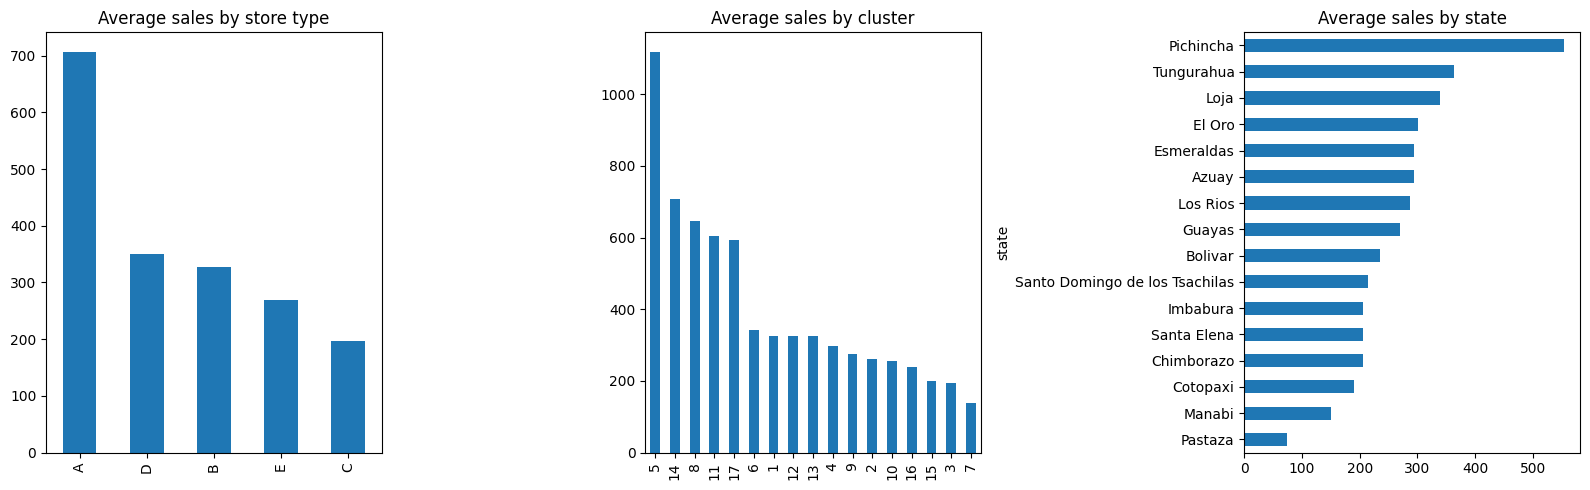

In [50]:
# Stores: type, cluster, region / Магазины: тип, кластер, регион

train_stores = train.merge(stores, on="store_nbr", how="left")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average sales by store type / Средние продажи по типу магазина
train_stores.groupby("type")["sales"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], title="Average sales by store type"
)
axes[0].set_xlabel("")

# Average sales by cluster / Средние продажи по кластеру
train_stores.groupby("cluster")["sales"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], title="Average sales by cluster"
)
axes[1].set_xlabel("")

# Average sales by state / Средние продажи по штату
train_stores.groupby("state")["sales"].mean().sort_values().plot(
    kind="barh", ax=axes[2], title="Average sales by state"
)
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()


#### Store analysis — conclusions

**Store type** is a strong categorical feature: type A stores sell noticeably more than types C and E.

**Cluster** also matters: average sales differ a lot between clusters.

**Geography** is visible through state differences, but the final model uses the more direct store features: `store_nbr`, `store_type`, `cluster`.

**Summary:** stores are not homogeneous. Without store features the model would average very different demand patterns.

> 🇷🇺 Тип магазина — сильный признак (тип A продаёт заметно больше C и E), кластер тоже важен. География видна по штатам, но в модели используются более прямые признаки: `store_nbr`, `store_type`, `cluster`. Без них модель усредняла бы разные паттерны спроса.

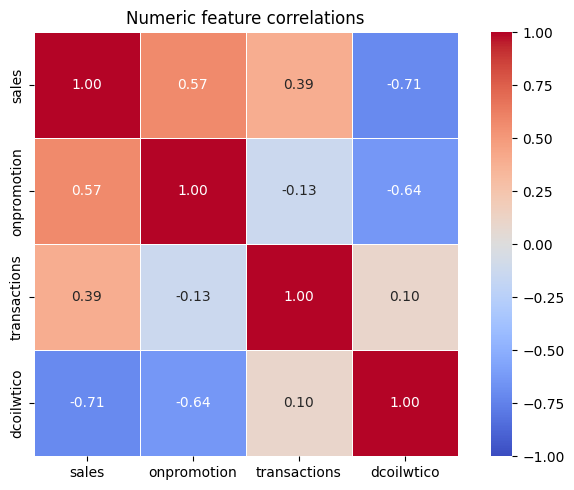

In [51]:
# Correlation matrix of numeric features / Матрица корреляций числовых признаков

# Collect features on daily aggregates / Собираем признаки на дневной агрегации
corr_df = (
    train.groupby("date")[["sales", "onpromotion"]]
    .mean()
    .merge(oil[["date", "dcoilwtico"]], on="date", how="left")
    .merge(
        transactions.groupby("date")["transactions"].mean().reset_index(),
        on="date", how="left"
    )
)

corr_matrix = corr_df[["sales", "onpromotion", "transactions", "dcoilwtico"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.show()


#### Numeric feature correlations — conclusions

The correlations below are computed on daily aggregates: sales, promotions and transactions are first averaged by date, then the correlation matrix is built.

| Pair | Correlation | Interpretation |
|---|---:|---|
| `sales` ↔ `onpromotion` | **+0.57** | Days with more promotions usually have higher sales |
| `sales` ↔ `transactions` | **+0.39** | More customer traffic comes with higher sales |
| `sales` ↔ `dcoilwtico` | **-0.71** | The oil price reflects macroeconomic demand dynamics |
| `onpromotion` ↔ `dcoilwtico` | **-0.64** | Promotions and oil move in opposite directions |
| `transactions` ↔ `dcoilwtico` | **+0.10** | Weak relation |

At the row level the `sales`–`onpromotion` relation is lower (**+0.43**) but still clear. So `onpromotion`, `dcoilwtico` and transaction lags are added to the model.

> 🇷🇺 Корреляции на дневной агрегации: продажи ↔ промо +0.57, продажи ↔ транзакции +0.39, продажи ↔ нефть −0.71. На уровне строк связь с промо ниже (+0.43), но заметная. Поэтому `onpromotion`, `dcoilwtico` и лаги транзакций добавлены в модель.

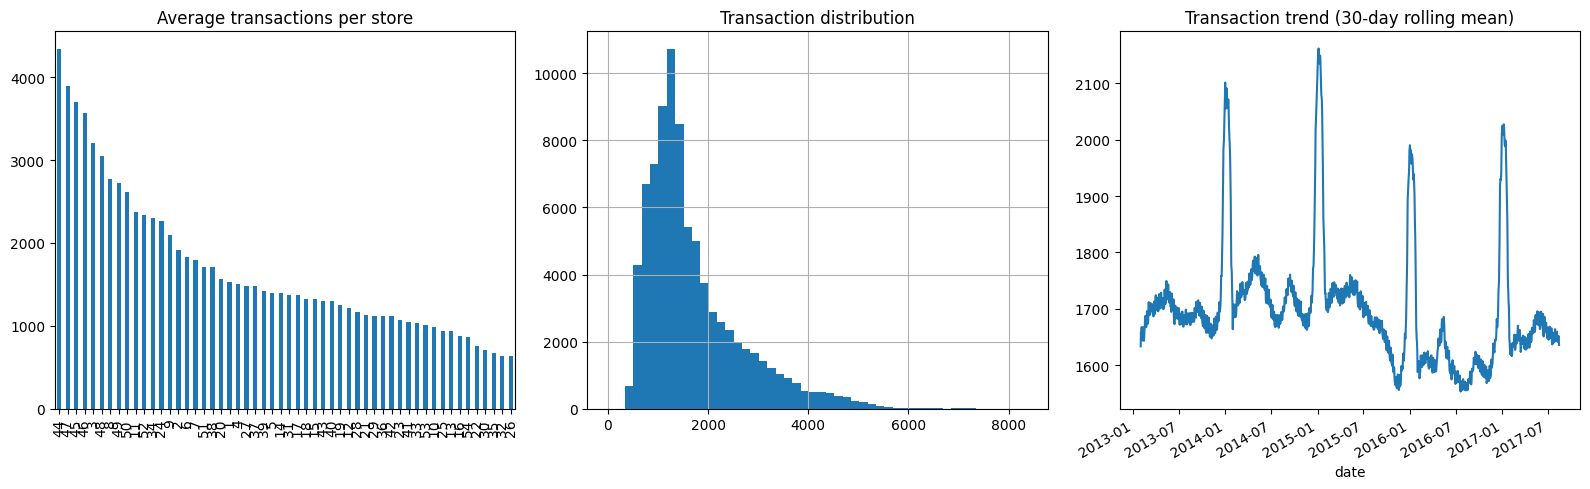

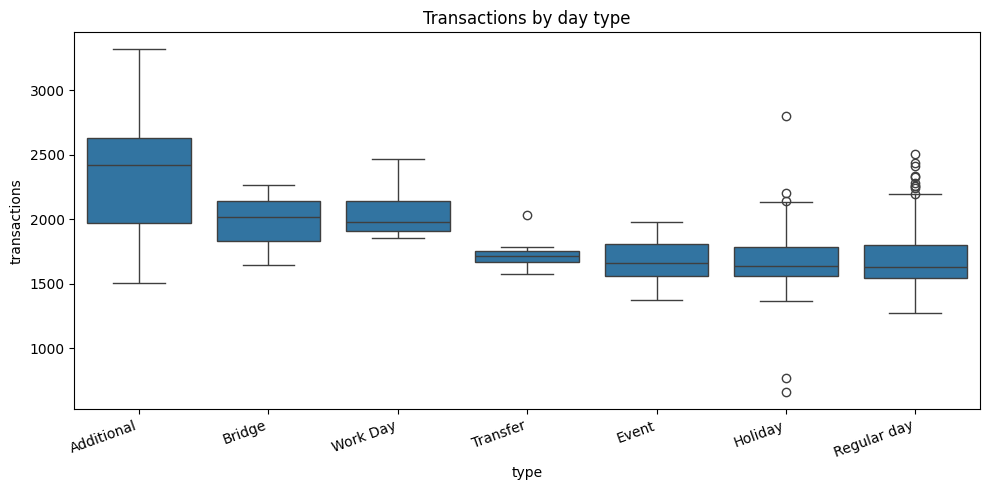

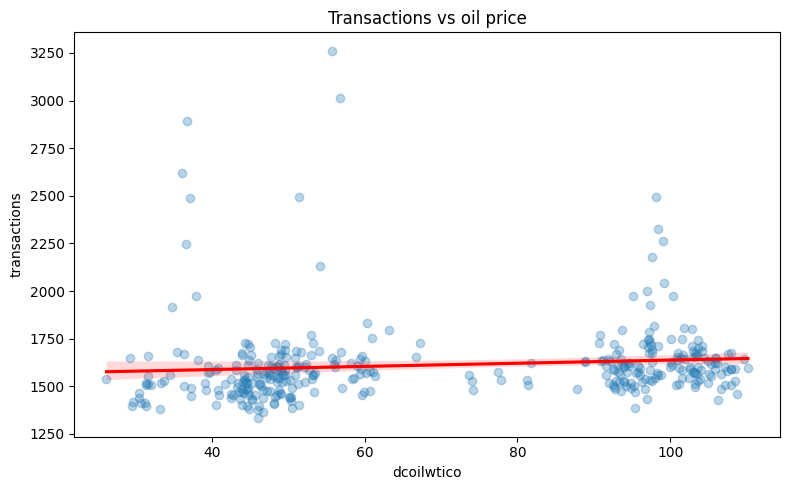

In [52]:
# Transaction analysis / Анализ транзакций

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average transactions per store / Средние транзакции по магазинам
(
    transactions.groupby("store_nbr")["transactions"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar", ax=axes[0], title="Average transactions per store")
)
axes[0].set_xlabel("")

# Transaction count distribution / Распределение количества транзакций
transactions["transactions"].hist(bins=50, ax=axes[1])
axes[1].set_title("Transaction distribution")

# Transaction trend, 30-day rolling mean / Тренд транзакций, 30-дневное среднее
(
    transactions.groupby("date")["transactions"]
    .mean()
    .rolling(30).mean()
    .plot(ax=axes[2], title="Transaction trend (30-day rolling mean)")
)

plt.tight_layout()
plt.show()

# Transactions by day type / Транзакции по типам дней

daily_trans = transactions.groupby("date")["transactions"].mean().reset_index()

daily_trans = daily_trans.merge(
    holidays[["date", "type"]].drop_duplicates("date"),
    on="date", how="left"
)
daily_trans["type"] = daily_trans["type"].fillna("Regular day")

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=daily_trans,
    x="type",
    y="transactions",
    order=daily_trans.groupby("type")["transactions"].median().sort_values(ascending=False).index
)
plt.title("Transactions by day type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Transactions vs oil price / Транзакции и цена нефти

trans_oil = daily_trans.merge(oil[["date", "dcoilwtico"]], on="date", how="left")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=trans_oil.sample(500, random_state=42),
    x="dcoilwtico",
    y="transactions",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Transactions vs oil price")
plt.tight_layout()
plt.show()

#### Transaction analysis — conclusions

**By store:** traffic differs a lot, so `store_nbr` matters.

**Trend:** the average number of transactions is fairly stable, so sales growth may come not only from traffic but also from the basket size and structure.

**By day type:** holidays and extra days off differ from regular days, so holiday features are useful.

**Transactions vs oil:** the relation is weak (about +0.10 on daily aggregates).

**How it is used in the model:** `transactions_lag_16`–`transactions_lag_23` are added. For the test period 2017-08-16 … 2017-08-31 these lags always fall into the train period, so no future transaction data is needed.

> 🇷🇺 Трафик сильно различается по магазинам; тренд транзакций стабилен (рост продаж — не только трафик); праздничные дни отличаются от обычных; связь с нефтью слабая. В модели — `transactions_lag_16`–`23`: для test-периода эти лаги всегда попадают в train, будущие транзакции не нужны.

### EDA summary

**Data**

- Panel time series: 54 stores × 33 product families × daily dates.
- After calendar reconstruction train contains 3,008,016 rows.
- `train` and `test` are consecutive: 2017-08-15 → 2017-08-16.
- `oil` is rebuilt to a daily series and filled with interpolation.
- December 25 is added to train with zero sales because stores are closed.

**Target**

- `sales` is strongly right-skewed, about 31% of observations are zero.
- Training uses `log1p(sales)`.
- The zero-rule is applied to series with no sales in the last 21 days.

**Time structure**

- STL: trend 0.838, seasonality 0.644.
- ACF/PACF confirm the importance of lag features.
- The model gets lags 1–6, 7/14/21/28/42/56, 364/365 and rolling means.

**External factors**

- `onpromotion` is related to sales growth.
- `dcoilwtico` carries a strong macroeconomic signal.
- `transactions` exist only in train, so safe lags 16–23 are used.

**Stores and products**

- `store_nbr`, `store_type`, `cluster` and `family` are required: stores and families differ in scale and demand patterns.

**Events**

- Holidays and events have different effects, so separate flags are added: national holidays, Black Friday, Cyber Monday, the earthquake, Navidad, Día de la Madre, fútbol and others.

> 🇷🇺 Итог EDA: панельный ряд 54×33, после восстановления календаря 3 008 016 строк; таргет скошен, 31% нулей → `log1p` + zero-rule; STL: тренд 0.838, сезонность 0.644 → лаги и rolling; промо и нефть — полезные внешние сигналы; транзакции — только безопасные лаги 16–23; признаки магазина/товара обязательны; для событий — отдельные флаги.

### EDA → Feature Engineering

| Feature group | Features | Why |
|---|---|---|
| Calendar | `day_of_week`, `month`, `year`, `is_weekend`, `day_of_year`, `week_of_year`, `date_index` | Weekly, monthly and long-term dynamics |
| Fourier | `sin_day`, `cos_day`, `sin_week`, `cos_week` | Smooth yearly and weekly cycles |
| Sales lags | `lag_1`–`lag_6`, `lag_7`, `lag_14`, `lag_21`, `lag_28`, `lag_42`, `lag_56`, `lag_364`, `lag_365` | Sales history per `store_nbr × family` |
| Rolling | `rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28`, `rolling_mean_364` | Smoothed demand history |
| Oil | `dcoilwtico`, `dcoilwtico_ma7`, `dcoilwtico_ma28` | Macroeconomic factor |
| Promotions | `onpromotion`, `onpromotion_ma7`, `onpromotion_ma28` | Current and smoothed promotions |
| Transactions | `transactions_lag_16`–`transactions_lag_23` | Known historical traffic without test leakage |
| Events | `is_holiday_national`, `day_before_holiday`, `is_black_friday`, `is_cyber_monday`, `is_terremoto`, `is_navidad`, `is_dia_madre`, `is_futbol`, `is_dia_trabajo`, `is_primer_dia`, `is_dia_difuntos`, `work_day` | Different effects of holidays and events |
| Store & product | `store_nbr`, `store_type`, `cluster`, `family` | Different demand scale across stores and families |

Initial `NaN` values in lag features are expected: the first days of history have no past data yet. LightGBM handles such missing values natively.

> 🇷🇺 Таблица признаков, выведенных из EDA: календарь, Fourier, лаги, rolling, нефть, промо, безопасные лаги транзакций, флаги событий, признаки магазина и товара. Начальные `NaN` в лагах ожидаемы — LightGBM умеет работать с пропусками.